# Chapter 48 — Embeddings: Token IDs Become Vectors

## Learning goals

Chapter 47 used `Embedding(vocabulary_size, vocabulary_size)` as a direct table of next-token logits.

This chapter uses a smaller output dimension so each token ID selects a vector that later neural-network layers can process.

By the end of this chapter, you should be able to:

1. Explain why a token ID is an arbitrary integer label rather than a numerical measurement.
2. Define an embedding table and embedding dimension.
3. Create and inspect `torch.nn.Embedding`.
4. Look up one token, a sequence, and a batch of token embeddings.
5. Apply the embedding shape rule.
6. Explain why IDs are integer tensors while embedding vectors are floating point.
7. Show that repeated IDs select identical rows.
8. Show embedding lookup as one-hot matrix multiplication.
9. Trace gradients into selected embedding rows.
10. Explain why nearby IDs are not automatically similar.
11. Demonstrate that an objective can train vectors to become more similar.
12. Pass embeddings into a downstream neural layer.

## The big idea

A token ID is an index into a table.

The table has one row per vocabulary token and one floating-point column per embedding dimension.

```text
token ID → selected table row → embedding vector
```

The ID determines which row is selected.

The row values, not the integer ID, are the trainable representation used by later computations.

## Terms used in this chapter

- A **token** is a unit of text such as a character, word piece, or word.
- A **token ID** is an integer index assigned to a vocabulary token.
- A **vector** is an ordered list of numbers.
- An **embedding** is a trainable vector associated with a token ID.
- An **embedding table** is a matrix whose rows are token vectors.
- The **vocabulary size** is the number of rows in the table.
- The **embedding dimension** is the number of values in each row.
- A **lookup** selects table rows with integer IDs.
- **Vector similarity** compares vector values rather than token-ID values.
- A **representation** is a numerical form that later model operations can process.

## Import PyTorch and stay on CPU

Use explicit dtypes and deterministic initialization.

No CUDA code is required.

In [1]:
import torch

device = "cpu"
RANDOM_SEED = 48

print("PyTorch version:", torch.__version__)
print("Course device:", device)
print("Random seed:", RANDOM_SEED)

assert device == "cpu"

PyTorch version: 2.2.2
Course device: cpu
Random seed: 48


## Build a tiny vocabulary

Vocabulary order determines the assigned IDs.

The words are deliberately varied so the difference between arbitrary labels and learned relationships is easy to discuss.

In [2]:
vocabulary = [
    "apple",
    "banana",
    "cat",
    "dog",
    "elephant",
    "fish",
    "grape",
    "hat",
]
vocabulary_size = len(vocabulary)

token_to_id = {token: token_id for token_id, token in enumerate(vocabulary)}
id_to_token = {token_id: token for token, token_id in token_to_id.items()}

print("Vocabulary:", vocabulary)
print("Token to ID:", token_to_id)
print("Vocabulary size:", vocabulary_size)

assert vocabulary_size == 8
assert token_to_id["cat"] == 2
assert token_to_id["dog"] == 3

Vocabulary: ['apple', 'banana', 'cat', 'dog', 'elephant', 'fish', 'grape', 'hat']
Token to ID: {'apple': 0, 'banana': 1, 'cat': 2, 'dog': 3, 'elephant': 4, 'fish': 5, 'grape': 6, 'hat': 7}
Vocabulary size: 8


The IDs reflect list positions only.

They do not encode category, frequency, spelling, or semantic distance.

## ID arithmetic has no semantic meaning

Subtract the IDs for `dog` and `cat`.

The result describes their positions in this particular list, not how related the words are.

In [3]:
cat_id = token_to_id["cat"]
dog_id = token_to_id["dog"]
id_difference = dog_id - cat_id

print("cat ID:", cat_id)
print("dog ID:", dog_id)
print("dog ID - cat ID:", id_difference)

assert id_difference == 1

cat ID: 2
dog ID: 3
dog ID - cat ID: 1


The numerical difference happens to be one.

A different valid vocabulary ordering changes that difference without changing either token.

## Reordering the vocabulary changes IDs

Reverse the list and rebuild the mapping.

The same words now receive different labels.

In [4]:
reversed_vocabulary = list(reversed(vocabulary))
reversed_token_to_id = {
    token: token_id for token_id, token in enumerate(reversed_vocabulary)
}

print("Original cat ID:", token_to_id["cat"])
print("Reversed-order cat ID:", reversed_token_to_id["cat"])
print("Original dog ID:", token_to_id["dog"])
print("Reversed-order dog ID:", reversed_token_to_id["dog"])

assert token_to_id["cat"] != reversed_token_to_id["cat"]
assert token_to_id["dog"] != reversed_token_to_id["dog"]

Original cat ID: 2
Reversed-order cat ID: 5
Original dog ID: 3
Reversed-order dog ID: 4


A model remains equivalent after a consistent ID remapping and matching row permutation.

Meaning cannot live in the arbitrary index itself.

## Store token IDs as integers

Encode a short sequence with a repeated token.

PyTorch embedding lookup expects integer index tensors, usually `torch.long`.

In [5]:
input_tokens = ["fish", "cat", "fish", "hat"]
input_token_ids = torch.tensor(
    [token_to_id[token] for token in input_tokens],
    dtype=torch.long,
    device=device,
)

print("Input tokens:", input_tokens)
print("Input token IDs:", input_token_ids)
print("ID shape:", input_token_ids.shape)
print("ID dtype:", input_token_ids.dtype)
print("IDs require gradients:", input_token_ids.requires_grad)

assert input_token_ids.tolist() == [5, 2, 5, 7]
assert input_token_ids.shape == torch.Size([4])
assert input_token_ids.dtype == torch.long
assert not input_token_ids.requires_grad

Input tokens: ['fish', 'cat', 'fish', 'hat']
Input token IDs: tensor([5, 2, 5, 7])
ID shape: torch.Size([4])
ID dtype: torch.int64
IDs require gradients: False


Integer IDs select rows and do not receive gradients.

Floating-point table rows receive gradients through computations that use their values.

## Create an embedding table

Choose an embedding dimension smaller than the vocabulary size.

This differs from Chapter 47, where each selected row was already a vocabulary-sized logit vector.

In [6]:
embedding_dimension = 4

torch.manual_seed(RANDOM_SEED)
embedding_table = torch.nn.Embedding(
    num_embeddings=vocabulary_size,
    embedding_dim=embedding_dimension,
    device=device,
)

print(embedding_table)
print("Weight shape:", embedding_table.weight.shape)
print("Weight dtype:", embedding_table.weight.dtype)
print("Weight device:", embedding_table.weight.device)
print("Requires gradients:", embedding_table.weight.requires_grad)

assert embedding_table.weight.shape == torch.Size([8, 4])
assert embedding_table.weight.dtype == torch.float32
assert embedding_table.weight.device.type == "cpu"
assert embedding_table.weight.requires_grad

Embedding(8, 4)
Weight shape: torch.Size([8, 4])
Weight dtype: torch.float32
Weight device: cpu
Requires gradients: True


The table contains `vocabulary_size × embedding_dimension = 32` trainable scalar values.

At initialization, these values are random parameters rather than learned semantic features.

## Look up one token vector

Pass a one-element ID tensor to obtain one row while preserving a batch-like leading dimension.

In [7]:
fish_id_tensor = torch.tensor(
    [token_to_id["fish"]],
    dtype=torch.long,
    device=device,
)
fish_embedding = embedding_table(fish_id_tensor)

print("Token ID:", fish_id_tensor)
print("Token:", id_to_token[int(fish_id_tensor.item())])
print("Embedding:")
print(fish_embedding)
print("Embedding shape:", fish_embedding.shape)

assert fish_embedding.shape == torch.Size([1, embedding_dimension])
torch.testing.assert_close(
    fish_embedding,
    embedding_table.weight[fish_id_tensor],
)

Token ID: tensor([5])
Token: fish
Embedding:
tensor([[ 0.3736, -0.2863, -0.0414, -1.6634]], grad_fn=<EmbeddingBackward0>)
Embedding shape: torch.Size([1, 4])


The input shape is `[1]`, and the output shape is `[1, embedding_dimension]`.

Direct row indexing produces the same values, although model code normally calls the embedding module.

## Look up a token sequence

Pass the complete one-dimensional ID tensor.

PyTorch appends the embedding dimension to the input shape.

In [8]:
token_embeddings = embedding_table(input_token_ids)

print("Token IDs:", input_token_ids)
print("Embeddings:")
print(token_embeddings)
print("Embedding shape:", token_embeddings.shape)

assert token_embeddings.shape == torch.Size([4, embedding_dimension])
assert token_embeddings.dtype == torch.float32

Token IDs: tensor([5, 2, 5, 7])
Embeddings:
tensor([[ 0.3736, -0.2863, -0.0414, -1.6634],
        [-1.1368, -0.4101,  0.2939,  0.1713],
        [ 0.3736, -0.2863, -0.0414, -1.6634],
        [-1.6273, -0.2667, -0.8868,  0.1195]], grad_fn=<EmbeddingBackward0>)
Embedding shape: torch.Size([4, 4])


Four integer labels became four floating-point vectors.

The embedding vectors can now participate in multiplication, addition, normalization, and other differentiable operations.

## Label the selected rows

Print each token beside the vector returned at its sequence position.

In [9]:
print("position | token ID | token | embedding vector")
print("-" * 82)

for position, (token_id_tensor, embedding_vector) in enumerate(
    zip(input_token_ids, token_embeddings, strict=True)
):
    token_id = int(token_id_tensor.item())
    print(
        f"{position:>8} | "
        f"{token_id:>8} | "
        f"{id_to_token[token_id]:>5} | "
        f"{embedding_vector.detach().tolist()}"
    )

position | token ID | token | embedding vector
----------------------------------------------------------------------------------
       0 |        5 |  fish | [0.3735780119895935, -0.28629282116889954, -0.04144096374511719, -1.6634080410003662]
       1 |        2 |   cat | [-1.1368192434310913, -0.41007199883461, 0.29390859603881836, 0.17130203545093536]
       2 |        5 |  fish | [0.3735780119895935, -0.28629282116889954, -0.04144096374511719, -1.6634080410003662]
       3 |        7 |   hat | [-1.6273024082183838, -0.266672819852829, -0.8867689967155457, 0.11948073655366898]


The ID `5` appears at positions zero and two.

Both positions selected the same table row.

## Repeated IDs produce repeated vectors

Verify the repeated lookup directly.

The vectors are identical before any later context-dependent processing.

In [10]:
first_fish_embedding = token_embeddings[0]
second_fish_embedding = token_embeddings[2]

print("First fish embedding:", first_fish_embedding)
print("Second fish embedding:", second_fish_embedding)
print(
    "Equal?",
    torch.equal(first_fish_embedding, second_fish_embedding),
)

assert torch.equal(first_fish_embedding, second_fish_embedding)

First fish embedding: tensor([ 0.3736, -0.2863, -0.0414, -1.6634], grad_fn=<SelectBackward0>)
Second fish embedding: tensor([ 0.3736, -0.2863, -0.0414, -1.6634], grad_fn=<SelectBackward0>)
Equal? True


Token embedding lookup alone is context independent.

The same token ID receives the same row at every sequence position.

## Look up a batch of sequences

A common language-model ID shape is `[batch_size, context_length]`.

Embedding lookup adds one final dimension.

In [11]:
batch_token_ids = torch.tensor(
    [
        [5, 2, 5],
        [1, 6, 0],
    ],
    dtype=torch.long,
    device=device,
)
batch_token_embeddings = embedding_table(batch_token_ids)

print("Batch IDs:")
print(batch_token_ids)
print("Batch ID shape:", batch_token_ids.shape)
print("Batch embeddings:")
print(batch_token_embeddings)
print("Batch embedding shape:", batch_token_embeddings.shape)

assert batch_token_ids.shape == torch.Size([2, 3])
assert batch_token_embeddings.shape == torch.Size([2, 3, embedding_dimension])

Batch IDs:
tensor([[5, 2, 5],
        [1, 6, 0]])
Batch ID shape: torch.Size([2, 3])
Batch embeddings:
tensor([[[ 0.3736, -0.2863, -0.0414, -1.6634],
         [-1.1368, -0.4101,  0.2939,  0.1713],
         [ 0.3736, -0.2863, -0.0414, -1.6634]],

        [[-1.5123,  0.1660, -1.1459,  0.0613],
         [-0.4969,  1.4880,  0.6980, -0.2851],
         [ 0.0770, -0.4779,  0.6854, -0.6775]]], grad_fn=<EmbeddingBackward0>)
Batch embedding shape: torch.Size([2, 3, 4])


The shape rule is:

```text
embedding output shape = token-ID input shape + [embedding dimension]
```

For this batch, `[2, 3]` becomes `[2, 3, 4]`.

## Draw IDs selecting table rows

This diagram makes the lookup operation visible.

Arrows point from the IDs used in the sequence to their table rows.

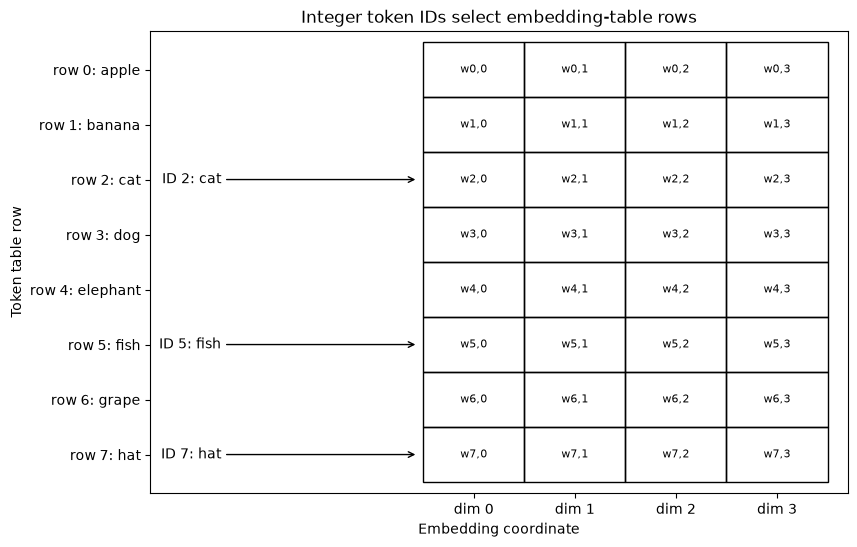

In [12]:
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

figure, axis = plt.subplots(figsize=(9, 6))

for row_index in range(vocabulary_size):
    for column_index in range(embedding_dimension):
        rectangle = Rectangle(
            (column_index, vocabulary_size - 1 - row_index),
            1,
            1,
            fill=False,
            edgecolor="black",
        )
        axis.add_patch(rectangle)
        axis.text(
            column_index + 0.5,
            vocabulary_size - 1 - row_index + 0.5,
            f"w{row_index},{column_index}",
            ha="center",
            va="center",
            fontsize=8,
        )

for selected_token_id in sorted(set(input_token_ids.tolist())):
    vertical_position = vocabulary_size - 1 - selected_token_id + 0.5
    axis.annotate(
        f"ID {selected_token_id}: {id_to_token[selected_token_id]}",
        xy=(-0.05, vertical_position),
        xytext=(-2.0, vertical_position),
        arrowprops={"arrowstyle": "->"},
        va="center",
        ha="right",
    )

axis.set_xlim(-2.7, embedding_dimension + 0.2)
axis.set_ylim(-0.2, vocabulary_size + 0.2)
axis.set_xticks(
    [column_index + 0.5 for column_index in range(embedding_dimension)],
    [f"dim {column_index}" for column_index in range(embedding_dimension)],
)
axis.set_yticks(
    [vocabulary_size - 1 - row_index + 0.5 for row_index in range(vocabulary_size)],
    [
        f"row {row_index}: {id_to_token[row_index]}"
        for row_index in range(vocabulary_size)
    ],
)
axis.set_xlabel("Embedding coordinate")
axis.set_ylabel("Token table row")
axis.set_title("Integer token IDs select embedding-table rows")
axis.grid(False)
plt.show()

Each selected row contains four floating-point coordinates.

The diagram represents lookup structure, not similarity between rows.

## One-hot multiplication gives the same result

A one-hot row has one at the token ID and zero elsewhere.

Multiplying one-hot rows by the embedding weight matrix selects the same rows as direct lookup.

In [13]:
one_hot_token_rows = torch.nn.functional.one_hot(
    input_token_ids,
    num_classes=vocabulary_size,
).to(torch.float32)

embeddings_from_one_hot = one_hot_token_rows @ embedding_table.weight

print("One-hot shape:", one_hot_token_rows.shape)
print("Result shape:", embeddings_from_one_hot.shape)

torch.testing.assert_close(
    embeddings_from_one_hot,
    token_embeddings,
)

One-hot shape: torch.Size([4, 8])
Result shape: torch.Size([4, 4])


Direct lookup avoids constructing large mostly-zero one-hot vectors.

With a vocabulary of 50,000 tokens, each one-hot row would contain 49,999 zeros.

## Trace gradients into selected rows

Use the sum of selected embeddings as a deliberately simple diagnostic loss.

This is not a language-model objective; it only makes row-gradient accumulation easy to verify.

In [14]:
embedding_table.zero_grad(set_to_none=True)

diagnostic_embeddings = embedding_table(input_token_ids)
diagnostic_loss = diagnostic_embeddings.sum()
diagnostic_loss.backward()

embedding_gradients = embedding_table.weight.grad

print("Diagnostic loss:", diagnostic_loss.item())
print("Embedding gradients:")
print(embedding_gradients)

assert embedding_gradients is not None

expected_embedding_gradients = torch.zeros_like(embedding_table.weight)
expected_embedding_gradients[2] = 1.0
expected_embedding_gradients[5] = 2.0
expected_embedding_gradients[7] = 1.0

torch.testing.assert_close(
    embedding_gradients,
    expected_embedding_gradients,
)

Diagnostic loss: -6.978071689605713
Embedding gradients:
tensor([[0., 0., 0., 0.],
        [0., 0., 0., 0.],
        [1., 1., 1., 1.],
        [0., 0., 0., 0.],
        [0., 0., 0., 0.],
        [2., 2., 2., 2.],
        [0., 0., 0., 0.],
        [1., 1., 1., 1.]])


Rows `2`, `5`, and `7` were selected, so only those rows received nonzero gradients.

Row `5` was selected twice, so its gradient contribution is doubled.

## Integer IDs cannot receive ordinary gradients

Attempting to create a gradient-tracked integer index tensor fails.

The table values are differentiable; the lookup keys are not.

In [15]:
try:
    torch.tensor(
        [5, 2, 5, 7],
        dtype=torch.long,
        device=device,
        requires_grad=True,
    )
except RuntimeError as integer_gradient_error:
    print("Integer gradient request failed as expected:")
    print(integer_gradient_error)
else:
    raise AssertionError("Integer IDs should not accept gradients.")

Integer gradient request failed as expected:
Only Tensors of floating point and complex dtype can require gradients


This distinction mirrors database-like lookup.

An index chooses data, while learning changes the floating-point values stored at selected rows.

## Similarity lives in vectors

Adjacent IDs do not guarantee nearby embedding vectors.

Compare Euclidean distances for several token pairs in the randomly initialized table.

In [16]:
def embedding_distance(
    first_token_id: int,
    second_token_id: int,
    table: torch.nn.Embedding,
) -> float:
    first_vector = table.weight[first_token_id].detach()
    second_vector = table.weight[second_token_id].detach()
    return float(torch.linalg.vector_norm(first_vector - second_vector).item())


pairs_to_compare = [
    ("fish", "grape"),
    ("apple", "hat"),
    ("cat", "dog"),
    ("banana", "grape"),
]

print("first token | second token | ID gap | vector distance")
print("-" * 61)

for first_token, second_token in pairs_to_compare:
    first_id = token_to_id[first_token]
    second_id = token_to_id[second_token]

    print(
        f"{first_token:>11} | "
        f"{second_token:>12} | "
        f"{abs(first_id - second_id):>6} | "
        f"{embedding_distance(first_id, second_id, embedding_table):>15.6f}"
    )

first token | second token | ID gap | vector distance
-------------------------------------------------------------
       fish |        grape |      1 |        2.520374
      apple |          hat |      7 |        2.460940
        cat |          dog |      1 |        3.382380
     banana |        grape |      5 |        2.509646


No monotonic relationship connects ID gap with vector distance.

The initial distances come from random table values, not token meaning.

## A toy similarity objective

Train a separate table to make the `apple` and `banana` vectors close.

This artificial objective is only a mechanism demonstration; real language-model embeddings are trained because they help predict tokens.

In [17]:
torch.manual_seed(RANDOM_SEED)
toy_embedding_table = torch.nn.Embedding(
    vocabulary_size,
    embedding_dimension,
    device=device,
)
apple_id_tensor = torch.tensor(
    [token_to_id["apple"]],
    dtype=torch.long,
    device=device,
)
banana_id_tensor = torch.tensor(
    [token_to_id["banana"]],
    dtype=torch.long,
    device=device,
)
toy_optimizer = torch.optim.AdamW(
    toy_embedding_table.parameters(),
    lr=0.05,
    weight_decay=0.0,
)

initial_apple_banana_distance = embedding_distance(
    token_to_id["apple"],
    token_to_id["banana"],
    toy_embedding_table,
)

for _ in range(100):
    apple_embedding = toy_embedding_table(apple_id_tensor)
    banana_embedding = toy_embedding_table(banana_id_tensor)
    similarity_loss = ((apple_embedding - banana_embedding) ** 2).mean()

    toy_optimizer.zero_grad(set_to_none=True)
    similarity_loss.backward()
    toy_optimizer.step()

final_apple_banana_distance = embedding_distance(
    token_to_id["apple"],
    token_to_id["banana"],
    toy_embedding_table,
)

print("Initial vector distance:", initial_apple_banana_distance)
print("Final vector distance:", final_apple_banana_distance)

assert final_apple_banana_distance < (initial_apple_banana_distance * 0.01)

Initial vector distance: 2.615323543548584
Final vector distance: 0.009010441601276398


The vectors moved close because the loss and optimizer pushed them together.

Their IDs did not change and did not cause the similarity.

## Visualize the initialized table

A heatmap shows rows and embedding coordinates.

The values in the main table remain at their deterministic random initialization because the earlier diagnostic backward pass did not call an optimizer step.

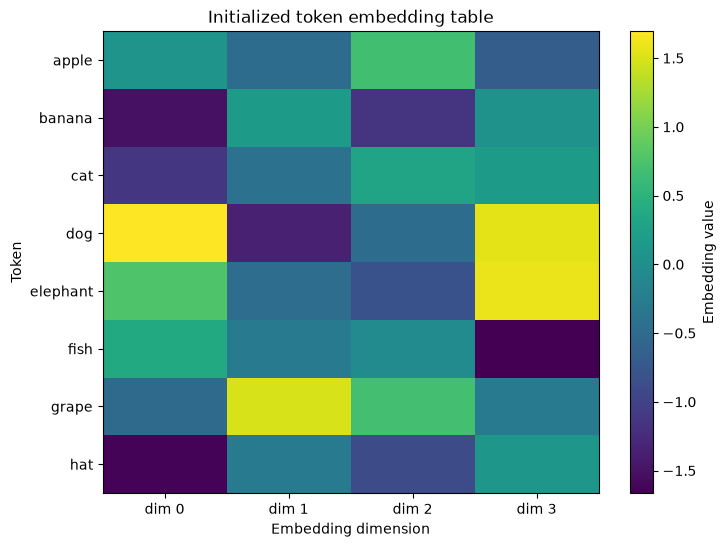

In [18]:
initialized_embedding_weights = embedding_table.weight.detach().clone()

plt.figure(figsize=(8, 6))
plt.imshow(
    initialized_embedding_weights.cpu().numpy(),
    aspect="auto",
)
plt.colorbar(label="Embedding value")
plt.xticks(
    ticks=list(range(embedding_dimension)),
    labels=[f"dim {dimension_index}" for dimension_index in range(embedding_dimension)],
)
plt.yticks(
    ticks=list(range(vocabulary_size)),
    labels=[id_to_token[token_id] for token_id in range(vocabulary_size)],
)
plt.xlabel("Embedding dimension")
plt.ylabel("Token")
plt.title("Initialized token embedding table")
plt.show()

Each row is one token vector.

Individual coordinates have no built-in human interpretation, and random colors do not yet express learned semantic structure.

## Feed embeddings into a neural layer

A downstream linear layer consumes floating-point vectors along the final dimension.

Here it maps each four-dimensional token vector to three arbitrary output features.

In [19]:
torch.manual_seed(RANDOM_SEED)
feature_projection = torch.nn.Linear(
    in_features=embedding_dimension,
    out_features=3,
    device=device,
)
projected_features = feature_projection(batch_token_embeddings)

print("Embedding shape:", batch_token_embeddings.shape)
print("Projected shape:", projected_features.shape)
print("Projected dtype:", projected_features.dtype)

assert projected_features.shape == torch.Size([2, 3, 3])
assert projected_features.dtype == torch.float32

Embedding shape: torch.Size([2, 3, 4])
Projected shape: torch.Size([2, 3, 3])
Projected dtype: torch.float32


The batch and context dimensions remain in place.

The final embedding dimension is the feature axis transformed by the linear layer.

## Embedding dimension controls capacity and cost

The parameter count is:

```text
vocabulary size × embedding dimension
```

A larger dimension gives every token more trainable coordinates and increases memory and computation.

In [20]:
def count_embedding_parameters(
    vocabulary_size: int,
    embedding_dimension: int,
) -> int:
    return vocabulary_size * embedding_dimension


embedding_configurations = [
    (8, 4),
    (100, 32),
    (1_000, 128),
    (50_000, 768),
]

print("vocabulary | dimension | parameters")
print("-" * 39)

for configuration_vocabulary_size, configuration_dimension in embedding_configurations:
    parameter_count = count_embedding_parameters(
        configuration_vocabulary_size,
        configuration_dimension,
    )
    print(
        f"{configuration_vocabulary_size:>10} | "
        f"{configuration_dimension:>9} | "
        f"{parameter_count:>10}"
    )

assert count_embedding_parameters(8, 4) == 32
assert count_embedding_parameters(50_000, 768) == 38_400_000

vocabulary | dimension | parameters
---------------------------------------
         8 |         4 |         32
       100 |        32 |       3200
      1000 |       128 |     128000
     50000 |       768 |   38400000


A 50,000-token vocabulary with dimension 768 contains 38.4 million embedding parameters.

Unlike Chapter 47's direct `vocabulary_size²` logit table, this count grows linearly with the chosen embedding dimension.

## Score tables and token embeddings serve different roles

| Chapter 47 score table | Chapter 48 token embedding table |
|---|---|
| Row length equals vocabulary size | Row length is a chosen embedding dimension |
| Row values are next-token logits | Row values are intermediate features |
| Can feed directly into cross-entropy | Needs later layers to produce task outputs |
| Parameter count is vocabulary size squared | Parameter count is vocabulary size times embedding dimension |

Both use integer lookup, but their selected vectors have different meanings in the model.

## Embeddings do not encode position

The same token ID receives the same token embedding at every sequence position.

The sequences `dog bites man` and `man bites dog` contain the same token identities in different orders.

Token embeddings provide identity-related vectors, but another mechanism must tell the model where each vector appears.

## What not to do

- Do not treat token IDs as continuous quantities.
- Do not feed floating-point IDs to an embedding lookup.
- Do not expect token IDs to receive gradients.
- Do not confuse the lookup key with the selected vector.
- Do not assume adjacent IDs have similar vectors.
- Do not describe random initialization as learned meaning.
- Do not expect embedding lookup alone to make a token context dependent.
- Do not forget that vocabulary size and embedding dimension determine parameter count.

## Gotchas

- Vocabulary order assigns arbitrary IDs.
- Embedding lookup appends one vector dimension to the ID-tensor shape.
- Repeated IDs select repeated vectors and accumulate row gradients.
- Unselected rows receive zero gradient from a dense embedding lookup's current loss.
- One-hot multiplication and direct lookup are mathematically equivalent.
- Similarity comes from trained vector values, not ID distance.
- Token embeddings alone do not represent sequence position.

## Takeaways

A token ID is an integer label used to select one row.

`torch.nn.Embedding(vocabulary_size, embedding_dimension)` stores one trainable floating-point vector per token ID.

A token sequence of shape `[context_length]` becomes embeddings of shape `[context_length, embedding_dimension]`.

A batch of shape `[batch_size, context_length]` becomes `[batch_size, context_length, embedding_dimension]`.

Gradients update selected table rows, while integer IDs remain fixed lookup keys.

Embedding similarity must be learned through an objective and data.

The resulting vectors provide numerical features that later neural-network layers can transform.

## What comes next

The next chapter adds position information to token embeddings.

Token embeddings identify which tokens occur, while positional embeddings distinguish where those tokens occur in a sequence.